Computing uniform integrals with max_deg=3...
Using 19 polynomial basis functions (degree 1..3)
Initial density std/mean: 0.663833
Step 0: density std/mean = 0.664224, max residual = 7.443210e-01, dt = 0.000141
Step 200: density std/mean = 0.672216, max residual = 2.802567e-01, dt = 0.005000
Step 400: density std/mean = 0.051972, max residual = 1.363014e-02, dt = 0.005000
Step 600: density std/mean = 0.047524, max residual = 6.633540e-04, dt = 0.005000
Step 800: density std/mean = 0.048418, max residual = 3.228430e-05, dt = 0.005000
Step 1000: density std/mean = 0.048281, max residual = 1.571222e-06, dt = 0.005000
Step 1200: density std/mean = 0.048287, max residual = 7.646869e-08, dt = 0.005000
Step 1400: density std/mean = 0.048287, max residual = 3.721600e-09, dt = 0.005000
Step 1600: density std/mean = 0.048287, max residual = 1.811240e-10, dt = 0.005000
Step 1800: density std/mean = 0.048287, max residual = 8.814974e-12, dt = 0.005000

Converged at step 1945
Final density std/mean

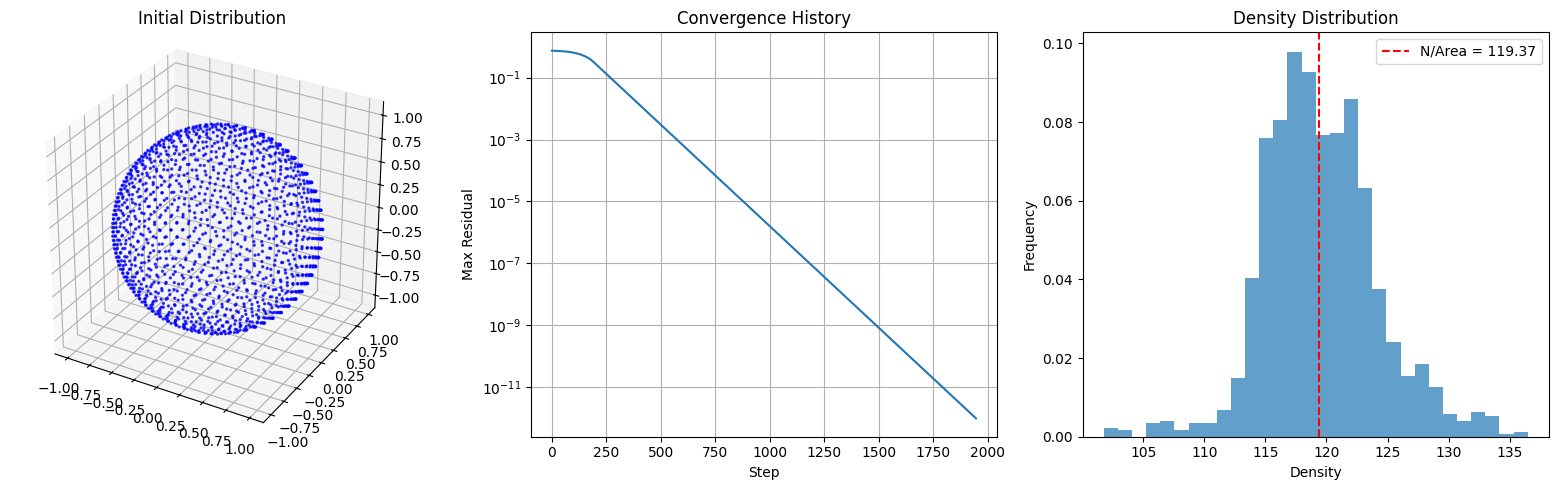

In [15]:
import numpy as np
from scipy.spatial import SphericalVoronoi
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================
# 0. 全局参数
# ============================================
N = 1500
MAX_DEG = 3          # 多项式最高次数
ALPHA = 3.0
DT = 0.005
MAX_STEPS = 2000
TOL = 1e-12
PROJECT_EVERY_STEP = True

# ============================================
# 1. 生成初始点云
# ============================================
def fibonacci_sphere(n, concentration=0.3):
    indices = np.arange(n)
    phi = np.arccos(1 - 2 * (indices + 0.5) / n)
    phi = phi ** concentration * np.pi / (np.pi ** concentration)
    phi = np.clip(phi, 0, np.pi)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    return np.column_stack([
        np.sin(phi) * np.cos(theta),
        np.sin(phi) * np.sin(theta),
        np.cos(phi)
    ])

# ============================================
# 2. 多项式基函数（次数 ≤ MAX_DEG，不含常数项）
# ============================================
def polynomial_basis(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    vals_list = []
    grads_list = []
    
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                v = (x**i) * (y**j) * (z**k)
                vals_list.append(v)
                
                gx = np.zeros(len(X)) if i == 0 else i * (x**(i-1)) * (y**j) * (z**k)
                gy = np.zeros(len(X)) if j == 0 else j * (x**i) * (y**(j-1)) * (z**k)
                gz = np.zeros(len(X)) if k == 0 else k * (x**i) * (y**j) * (z**(k-1))
                g = np.column_stack([gx, gy, gz])
                
                normal = X
                g_tangent = g - np.sum(g * normal, axis=1, keepdims=True) * normal
                grads_list.append(g_tangent)
    
    vals = np.column_stack(vals_list)
    grads = np.stack(grads_list, axis=1)
    return vals, grads

# ============================================
# 3. 计算均匀参考值
# ============================================
def compute_uniform_integral(n_samples=50000):
    phi = np.arccos(1 - 2 * np.random.rand(n_samples))
    theta = 2 * np.pi * np.random.rand(n_samples)
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    X_sample = np.column_stack([x, y, z])
    
    vals, _ = polynomial_basis(X_sample, MAX_DEG)
    return np.mean(vals, axis=0)

# ============================================
# 4. 密度估计
# ============================================
def estimate_density_std(X, k_neighbors=20):
    N_pts = len(X)
    local_density = np.zeros(N_pts)
    for i in range(N_pts):
        diff = X - X[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, k_neighbors+1)[1:k_neighbors+1]
        neighbors = X[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        local_area = np.pi * np.mean(dist_to_centroid)**2
        local_density[i] = k_neighbors / (local_area + 1e-12)
    return np.std(local_density) / np.mean(local_density)

# ============================================
# 5. 主算法
# ============================================
def main():
    X = fibonacci_sphere(N, concentration=0.3)
    total_area = 4 * np.pi
    
    print(f"Computing uniform integrals with max_deg={MAX_DEG}...")
    uniform_integrals = compute_uniform_integral(n_samples=50000)
    M_actual = len(uniform_integrals)
    print(f"Using {M_actual} polynomial basis functions (degree 1..{MAX_DEG})")
    print(f"Initial density std/mean: {estimate_density_std(X):.6f}")
    
    residual_history = []
    density_history = []
    
    for step in range(MAX_STEPS):
        vals, grads = polynomial_basis(X, MAX_DEG)
        
        A = np.zeros((M_actual, M_actual))
        b = np.zeros(M_actual)
        
        for m in range(M_actual):
            b[m] = -ALPHA * (np.mean(vals[:, m]) - uniform_integrals[m])
            for k in range(M_actual):
                A[m, k] = np.mean(np.sum(grads[:, k, :] * grads[:, m, :], axis=1))
        
        # SVD 求解
        U, s, Vt = np.linalg.svd(A)
        abs_tol = 1e-12
        rel_tol = max(s) * 1e-12
        tol = max(abs_tol, rel_tol)
        rank = np.sum(s > tol)
        
        s_inv = np.zeros_like(s)
        s_inv[:rank] = 1.0 / s[:rank]
        A_pinv = Vt.T @ np.diag(s_inv) @ U.T
        c = A_pinv @ b
        
        # 构造速度场
        v = np.zeros((N, 3))
        for k in range(M_actual):
            v += c[k] * grads[:, k, :]
        v = v - np.sum(v * X, axis=1, keepdims=True) * X
        
        v_norm = np.max(np.linalg.norm(v, axis=1))
        dt_effective = min(DT, 0.01 / (v_norm + 1e-8))
        
        # RK4
        def compute_velocity(X_pts):
            _, grads_t = polynomial_basis(X_pts, MAX_DEG)
            v_t = np.zeros_like(X_pts)
            for k in range(M_actual):
                v_t += c[k] * grads_t[:, k, :]
            return v_t - np.sum(v_t * X_pts, axis=1, keepdims=True) * X_pts
        
        k1 = compute_velocity(X)
        X1 = X + 0.5 * dt_effective * k1
        if PROJECT_EVERY_STEP:
            X1 = X1 / np.linalg.norm(X1, axis=1, keepdims=True)
        
        k2 = compute_velocity(X1)
        X2 = X + 0.5 * dt_effective * k2
        if PROJECT_EVERY_STEP:
            X2 = X2 / np.linalg.norm(X2, axis=1, keepdims=True)
        
        k3 = compute_velocity(X2)
        X3 = X + dt_effective * k3
        if PROJECT_EVERY_STEP:
            X3 = X3 / np.linalg.norm(X3, axis=1, keepdims=True)
        
        k4 = compute_velocity(X3)
        
        X_new = X + (dt_effective / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        if PROJECT_EVERY_STEP:
            X_new = X_new / np.linalg.norm(X_new, axis=1, keepdims=True)
        
        X = X_new
        
        max_residual = np.max(np.abs(b)) / ALPHA
        residual_history.append(max_residual)
        
        # 每200步检测一次密度
        if step % 200 == 0:
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            print(f"Step {step}: density std/mean = {density_std:.6f}, "
                  f"max residual = {max_residual:.6e}, dt = {dt_effective:.6f}")
        
        if max_residual < TOL:
            print(f"\nConverged at step {step}")
            break
    
    # 最终密度
    density_std = estimate_density_std(X)
    density_history.append(density_std)
    print(f"Final density std/mean: {density_std:.6f}")
    
    # 可视化
    fig = plt.figure(figsize=(16, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X[:, 0], X[:, 1], X[:, 2], s=2, c='blue', alpha=0.7)
    ax1.set_title('Initial Distribution')
    ax1.set_box_aspect([1, 1, 1])
    
    ax2 = fig.add_subplot(132)
    ax2.semilogy(residual_history)
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Max Residual')
    ax2.set_title('Convergence History')
    ax2.grid(True)
    
    # Voronoi 密度检查
    try:
        sv = SphericalVoronoi(X)
        sv.sort_vertices_of_regions()
        areas = sv.calculate_areas()
        rho = 1.0 / (areas + 1e-12)
        ax3 = fig.add_subplot(133)
        ax3.hist(rho, bins=30, density=True, alpha=0.7)
        ax3.axvline(N / total_area, color='r', linestyle='--', 
                   label=f'N/Area = {N/total_area:.2f}')
        ax3.set_xlabel('Density')
        ax3.set_ylabel('Frequency')
        ax3.set_title('Density Distribution')
        ax3.legend()
    except:
        pass
    
    plt.tight_layout()
    plt.show()
    
    return X, residual_history, density_history

if __name__ == "__main__":
    X_final, history, density_hist = main()

Generating 20 uniform centers for local basis...
Computing uniform reference values via weighted area method...
Using 20 Wendland C2 basis functions, epsilon=0.3
Initial density std/mean: 0.663833
Step 0: density std/mean = 0.663158, max residual = 3.438165e-01, dt = 0.000092, rank = 20/20
Step 50: density std/mean = 0.664514, max residual = 3.353792e-01, dt = 0.000287, rank = 20/20
Step 100: density std/mean = 0.707504, max residual = 3.120470e-01, dt = 0.000743, rank = 20/20
Step 150: density std/mean = 0.783628, max residual = 2.639142e-01, dt = 0.001652, rank = 20/20
Step 200: density std/mean = 0.787965, max residual = 1.807967e-01, dt = 0.003758, rank = 20/20
Step 250: density std/mean = 0.483397, max residual = 8.792441e-02, dt = 0.005000, rank = 20/20
Step 300: density std/mean = 0.228862, max residual = 4.131243e-02, dt = 0.005000, rank = 20/20
Step 350: density std/mean = 0.131552, max residual = 1.940679e-02, dt = 0.005000, rank = 20/20
Step 400: density std/mean = 0.107329,

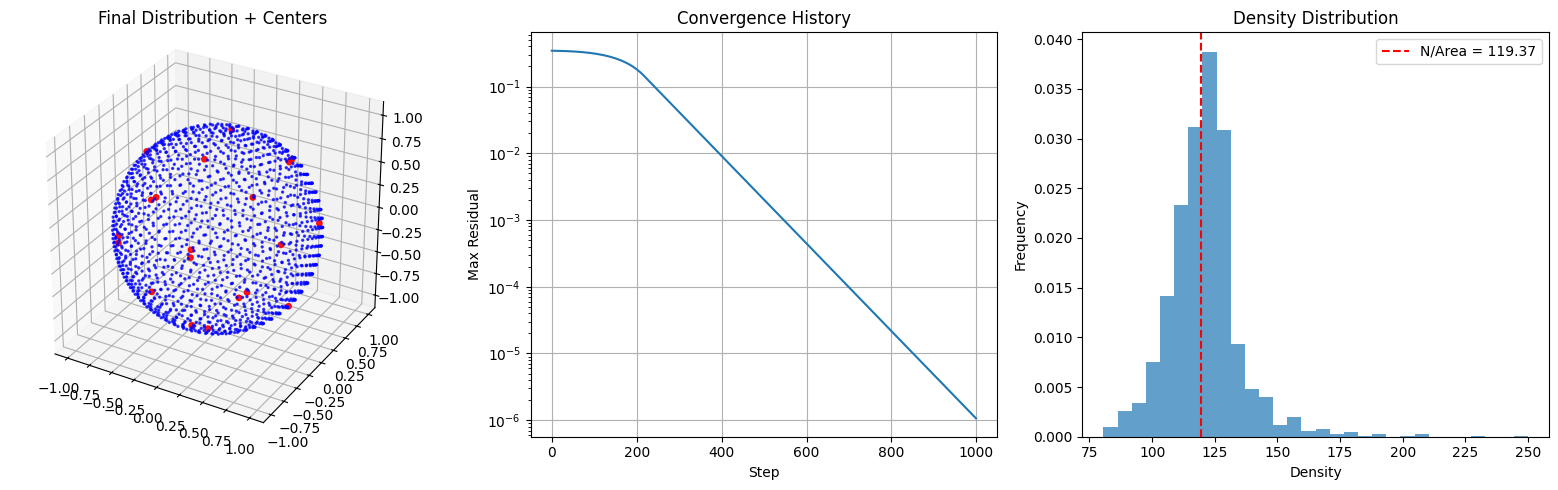

In [13]:
import numpy as np
from scipy.spatial import SphericalVoronoi
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================
# 0. 全局参数
# ============================================
N = 1500
N_LOCAL = 20        # Wendland 基函数数量
EPSILON = 0.3        # Wendland 支撑半径参数
ALPHA = 3.0
DT = 0.005
MAX_STEPS = 1000
TOL = 1e-12
PROJECT_EVERY_STEP = True

# ============================================
# 1. 生成初始点云
# ============================================
def fibonacci_sphere(n, concentration=0.3):
    indices = np.arange(n)
    phi = np.arccos(1 - 2 * (indices + 0.5) / n)
    phi = phi ** concentration * np.pi / (np.pi ** concentration)
    phi = np.clip(phi, 0, np.pi)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    return np.column_stack([
        np.sin(phi) * np.cos(theta),
        np.sin(phi) * np.sin(theta),
        np.cos(phi)
    ])

# ============================================
# 2. Wendland C2 局部基函数
# ============================================
def wendland_c2(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = (1 - q[mask])**4 * (4 * q[mask] + 1)
    return result

def wendland_c2_grad(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = -20 * epsilon * q[mask] * (1 - q[mask])**3
    return result

def local_basis_values(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    return wendland_c2(dist, epsilon)

def local_basis_gradients(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    dist_safe = np.where(dist < 1e-12, 1e-12, dist)
    dphi_dr = wendland_c2_grad(dist_safe, epsilon)
    grad_3d = dphi_dr[:, :, np.newaxis] * diff / dist_safe[:, :, np.newaxis]
    normal = X
    normal_proj = np.sum(grad_3d * normal[:, np.newaxis, :], axis=2)
    grad_tangent = grad_3d - normal_proj[:, :, np.newaxis] * normal[:, np.newaxis, :]
    return grad_tangent

# ============================================
# 3. 生成均匀基函数中心
# ============================================
def generate_uniform_centers(n_centers):
    indices = np.arange(5000)
    phi = np.arccos(1 - 2 * (indices + 0.5) / 5000)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    candidates = np.column_stack([
        np.sin(phi) * np.cos(theta),
        np.sin(phi) * np.sin(theta),
        np.cos(phi)
    ])
    
    selected = [np.random.randint(len(candidates))]
    min_dist = np.full(len(candidates), np.inf)
    for _ in range(n_centers - 1):
        last = candidates[selected[-1]]
        dist_to_last = np.linalg.norm(candidates - last, axis=1)
        min_dist = np.minimum(min_dist, dist_to_last)
        next_idx = np.argmax(min_dist)
        selected.append(next_idx)
        min_dist[next_idx] = -1
    
    return candidates[np.array(selected)]

# ============================================
# 4. 计算均匀参考值
# ============================================
def compute_uniform_reference(X_ref, centers, epsilon, n_neighbors=20):
    n_samples = len(X_ref)
    areas = np.zeros(n_samples)
    for i in range(n_samples):
        diff = X_ref - X_ref[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, n_neighbors+1)[1:n_neighbors+1]
        neighbors = X_ref[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        areas[i] = np.pi * np.mean(dist_to_centroid)**2
    
    psi = local_basis_values(X_ref, centers, epsilon)
    return np.average(psi, weights=areas, axis=0)

# ============================================
# 5. 密度估计
# ============================================
def estimate_density_std(X, k_neighbors=20):
    N_pts = len(X)
    local_density = np.zeros(N_pts)
    for i in range(N_pts):
        diff = X - X[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, k_neighbors+1)[1:k_neighbors+1]
        neighbors = X[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        local_area = np.pi * np.mean(dist_to_centroid)**2
        local_density[i] = k_neighbors / (local_area + 1e-12)
    return np.std(local_density) / np.mean(local_density)

# ============================================
# 6. 主算法
# ============================================
def main():
    X = fibonacci_sphere(N, concentration=0.3)
    total_area = 4 * np.pi
    
    print(f"Generating {N_LOCAL} uniform centers for local basis...")
    np.random.seed(42)
    centers = generate_uniform_centers(N_LOCAL)
    
    print(f"Computing uniform reference values via weighted area method...")
    X_ref = fibonacci_sphere(20000, concentration=1.0)
    uniform_avg = compute_uniform_reference(X_ref, centers, EPSILON)
    M_total = len(centers)
    print(f"Using {M_total} Wendland C2 basis functions, epsilon={EPSILON}")
    print(f"Initial density std/mean: {estimate_density_std(X):.6f}")
    
    residual_history = []
    density_history = []
    
    for step in range(MAX_STEPS):
        psi = local_basis_values(X, centers, EPSILON)
        grads = local_basis_gradients(X, centers, EPSILON)
        
        b = -ALPHA * (np.mean(psi, axis=0) - uniform_avg)
        
        A = np.zeros((M_total, M_total))
        for m in range(M_total):
            for k in range(M_total):
                A[m, k] = np.mean(np.sum(grads[:, k, :] * grads[:, m, :], axis=1))
        
        U, s, Vt = np.linalg.svd(A)
        abs_tol = 1e-12
        rel_tol = max(s) * 1e-12
        tol = max(abs_tol, rel_tol)
        rank = np.sum(s > tol)
        
        s_inv = np.zeros_like(s)
        s_inv[:rank] = 1.0 / s[:rank]
        A_pinv = Vt.T @ np.diag(s_inv) @ U.T
        c = A_pinv @ b
        
        v = np.sum(grads * c[np.newaxis, :, np.newaxis], axis=1)
        v = v - np.sum(v * X, axis=1, keepdims=True) * X
        
        v_norm = np.max(np.linalg.norm(v, axis=1))
        dt_effective = min(DT, 0.01 / (v_norm + 1e-8))
        
        # 欧拉一步
        X = X + dt_effective * v
        if PROJECT_EVERY_STEP:
            X = X / np.linalg.norm(X, axis=1, keepdims=True)
        
        max_residual = np.max(np.abs(b)) / ALPHA
        residual_history.append(max_residual)
        
        if step % 50 == 0:
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            print(f"Step {step}: density std/mean = {density_std:.6f}, "
                  f"max residual = {max_residual:.6e}, dt = {dt_effective:.6f}, rank = {rank}/{M_total}")
        
        if max_residual < TOL:
            print(f"\nConverged at step {step}")
            break
    
    density_std = estimate_density_std(X)
    density_history.append(density_std)
    print(f"Final density std/mean: {density_std:.6f}")
    
    # 可视化
    fig = plt.figure(figsize=(16, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X[:, 0], X[:, 1], X[:, 2], s=2, c='blue', alpha=0.7)
    ax1.scatter(centers[:, 0], centers[:, 1], centers[:, 2], s=15, c='red', alpha=0.9)
    ax1.set_title('Final Distribution + Centers')
    ax1.set_box_aspect([1, 1, 1])
    
    ax2 = fig.add_subplot(132)
    ax2.semilogy(residual_history)
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Max Residual')
    ax2.set_title('Convergence History')
    ax2.grid(True)
    
    try:
        sv = SphericalVoronoi(X)
        sv.sort_vertices_of_regions()
        areas = sv.calculate_areas()
        rho = 1.0 / (areas + 1e-12)
        ax3 = fig.add_subplot(133)
        ax3.hist(rho, bins=30, density=True, alpha=0.7)
        ax3.axvline(N / total_area, color='r', linestyle='--', 
                   label=f'N/Area = {N/total_area:.2f}')
        ax3.set_xlabel('Density')
        ax3.set_ylabel('Frequency')
        ax3.set_title('Density Distribution')
        ax3.legend()
    except:
        pass
    
    plt.tight_layout()
    plt.show()
    
    return X, residual_history, density_history

if __name__ == "__main__":
    X_final, history, density_hist = main()

Sphere Uniformization - Local Basis Only
Local: 60 Wendland C2, epsilon=0.3
Min support: 10 pts
Reselect centers every: 800 steps
Initial density std/mean: 0.663833
Generated 60 uniform centers on sphere
Computing uniform reference values...
Done.

Main iteration (Euler Forward)
Step 0: density std/mean = 0.663425, max|b| = 1.125726e+00, v_max = 908.8693, active basis = 60/60
Step 50: density std/mean = 0.667676, max|b| = 1.117985e+00, v_max = 100.5759, active basis = 60/60
Step 100: density std/mean = 0.681450, max|b| = 1.090868e+00, v_max = 35.4192, active basis = 60/60
Step 150: density std/mean = 0.717530, max|b| = 1.016086e+00, v_max = 13.8369, active basis = 60/60
Step 200: density std/mean = 0.773574, max|b| = 8.576026e-01, v_max = 6.0568, active basis = 60/60
Step 250: density std/mean = 0.786077, max|b| = 5.811800e-01, v_max = 2.6140, active basis = 60/60
Step 300: density std/mean = 0.505703, max|b| = 2.799669e-01, v_max = 1.0427, active basis = 60/60
Step 350: density std/me

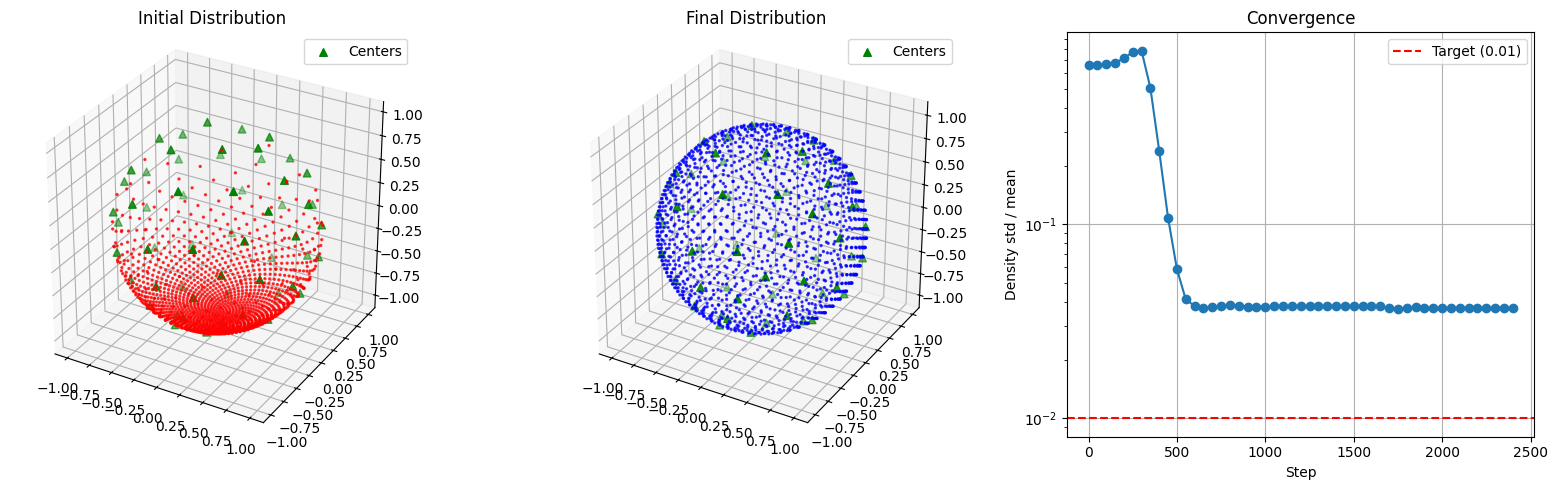


Final density std/mean: 0.037040


In [18]:
import numpy as np
from scipy.spatial import SphericalVoronoi
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================================
# 0. 全局参数
# ============================================================
N = 1500
N_LOCAL = 60
EPSILON = 0.3
K_NEIGHBORS = 20
ALPHA = 3.0
DT = 0.005
MAX_STEPS = 2400
TARGET_STD = 0.01
VELOCITY_TOL = 1e-10
MIN_SUPPORT = 10
SUPPORT_THRESHOLD = 1e-6
RESELECT_INTERVAL = 800

# ============================================================
# 1. 生成初始点云
# ============================================================
def fibonacci_sphere(n, concentration=0.3):
    indices = np.arange(n)
    phi = np.arccos(1 - 2 * (indices + 0.5) / n)
    phi = phi ** concentration * np.pi / (np.pi ** concentration)
    phi = np.clip(phi, 0, np.pi)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    return np.column_stack([
        np.sin(phi) * np.cos(theta),
        np.sin(phi) * np.sin(theta),
        np.cos(phi)
    ])

# ============================================================
# 2. Wendland C2 局部基函数
# ============================================================
def wendland_c2(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = (1 - q[mask])**4 * (4 * q[mask] + 1)
    return result

def wendland_c2_grad(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = -20 * epsilon * q[mask] * (1 - q[mask])**3
    return result

def local_basis_values(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    return wendland_c2(dist, epsilon)

def local_basis_gradients_tangent(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    dist_safe = np.where(dist < 1e-12, 1e-12, dist)
    dphi_dr = wendland_c2_grad(dist_safe, epsilon)
    grad_3d = dphi_dr[:, :, np.newaxis] * diff / dist_safe[:, :, np.newaxis]
    normal = X
    normal_proj = np.sum(grad_3d * normal[:, np.newaxis, :], axis=2)
    return grad_3d - normal_proj[:, :, np.newaxis] * normal[:, np.newaxis, :]

# ============================================================
# 3. 生成均匀基函数中心
# ============================================================
def generate_uniform_centers(n_centers):
    indices = np.arange(5000)
    phi = np.arccos(1 - 2 * (indices + 0.5) / 5000)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    candidates = np.column_stack([
        np.sin(phi) * np.cos(theta),
        np.sin(phi) * np.sin(theta),
        np.cos(phi)
    ])
    
    selected = [np.random.randint(len(candidates))]
    min_dist = np.full(len(candidates), np.inf)
    for _ in range(n_centers - 1):
        last = candidates[selected[-1]]
        dist_to_last = np.linalg.norm(candidates - last, axis=1)
        min_dist = np.minimum(min_dist, dist_to_last)
        next_idx = np.argmax(min_dist)
        selected.append(next_idx)
        min_dist[next_idx] = -1
    
    return candidates[np.array(selected)]

# ============================================================
# 4. 均匀参考值
# ============================================================
def compute_uniform_reference(centers, epsilon, n_samples=20000):
    X_ref = fibonacci_sphere(n_samples, concentration=1.0)
    
    areas = np.zeros(n_samples)
    for i in range(n_samples):
        diff = X_ref - X_ref[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, 21)[1:21]
        neighbors = X_ref[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        areas[i] = np.pi * np.mean(dist_to_centroid)**2
    
    psi_sample = local_basis_values(X_ref, centers, epsilon)
    return np.average(psi_sample, weights=areas, axis=0)

# ============================================================
# 5. 局部密度估计
# ============================================================
def estimate_density_std(X):
    N_pts = len(X)
    local_density = np.zeros(N_pts)
    for i in range(N_pts):
        diff = X - X[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, K_NEIGHBORS+1)[1:K_NEIGHBORS+1]
        neighbors = X[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        local_area = np.pi * np.mean(dist_to_centroid)**2
        local_density[i] = K_NEIGHBORS / (local_area + 1e-12)
    return np.std(local_density) / np.mean(local_density)

# ============================================================
# 6. 支撑修剪求解器
# ============================================================
def solve_with_support_pruning(X, centers, epsilon, uniform_avg, alpha,
                               min_support=5, support_threshold=1e-8):
    M_total = len(centers)
    
    psi = local_basis_values(X, centers, epsilon)
    support_counts = np.sum(np.abs(psi) > support_threshold, axis=0)
    valid_mask = support_counts >= min_support
    
    if np.sum(valid_mask) == 0:
        return np.zeros((len(X), 3)), np.zeros(M_total), valid_mask, support_counts
    
    psi_grad_full = local_basis_gradients_tangent(X, centers, epsilon)
    psi_valid = psi[:, valid_mask]
    psi_grad_valid = psi_grad_full[:, valid_mask, :]
    
    A_valid = np.mean(psi_grad_valid @ psi_grad_valid.transpose(0, 2, 1), axis=0)
    b_valid = -alpha * (np.mean(psi_valid, axis=0) - uniform_avg[valid_mask])
    
    c_valid = np.linalg.solve(A_valid, b_valid)
    
    c = np.zeros(M_total)
    c[valid_mask] = c_valid
    
    vT = np.sum(psi_grad_full * c[np.newaxis, :, np.newaxis], axis=1)
    # 投影到切空间
    vT = vT - np.sum(vT * X, axis=1, keepdims=True) * X
    
    return vT, c, valid_mask, support_counts

# ============================================================
# 7. 主程序
# ============================================================
def main():
    print("=" * 60)
    print("Sphere Uniformization - Local Basis Only")
    print(f"Local: {N_LOCAL} Wendland C2, epsilon={EPSILON}")
    print(f"Min support: {MIN_SUPPORT} pts")
    print(f"Reselect centers every: {RESELECT_INTERVAL} steps")
    print("=" * 60)
    
    X = fibonacci_sphere(N, concentration=0.3)
    X_initial = X.copy()
    
    density_std_initial = estimate_density_std(X)
    print(f"Initial density std/mean: {density_std_initial:.6f}")
    
    np.random.seed(42)
    centers = generate_uniform_centers(N_LOCAL)
    print(f"Generated {N_LOCAL} uniform centers on sphere")
    
    print("Computing uniform reference values...")
    uniform_avg = compute_uniform_reference(centers, EPSILON, n_samples=20000)
    print("Done.\n")
    
    density_history = [density_std_initial]
    
    print("=" * 60)
    print("Main iteration (Euler Forward)")
    print("=" * 60)
    
    for step in range(MAX_STEPS):
        if step > 0 and step % RESELECT_INTERVAL == 0:
            print(f"\nStep {step}: Reselecting basis centers...")
            centers = generate_uniform_centers(N_LOCAL)
            uniform_avg = compute_uniform_reference(centers, EPSILON, n_samples=20000)
            print(f"  New centers generated, reference values recomputed")
        
        vT, c, valid_mask, support_counts = solve_with_support_pruning(
            X, centers, EPSILON, uniform_avg, ALPHA,
            min_support=MIN_SUPPORT,
            support_threshold=SUPPORT_THRESHOLD
        )
        
        v_norm = np.max(np.linalg.norm(vT, axis=1))
        
        if v_norm < VELOCITY_TOL:
            print(f"\nVelocity converged at step {step}")
            break
        
        dt_effective = min(DT, 0.01 / (v_norm + 1e-8))
        
        X = X + dt_effective * vT
        X = X / np.linalg.norm(X, axis=1, keepdims=True)
        
        if step % 50 == 0:
            psi = local_basis_values(X, centers, EPSILON)
            b_full = -ALPHA * (np.mean(psi, axis=0) - uniform_avg)
            max_b = np.max(np.abs(b_full))
            
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            
            n_active = np.sum(valid_mask)
            
            print(f"Step {step}: density std/mean = {density_std:.6f}, "
                  f"max|b| = {max_b:.6e}, v_max = {v_norm:.4f}, "
                  f"active basis = {n_active}/{N_LOCAL}")
            
            if density_std < TARGET_STD:
                print(f"\nConverged at step {step}")
                break
    
    # 可视化
    total_area = 4 * np.pi
    fig = plt.figure(figsize=(16, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X_initial[:, 0], X_initial[:, 1], X_initial[:, 2], 
               s=2, c='red', alpha=0.7)
    ax1.scatter(centers[:, 0], centers[:, 1], centers[:, 2], 
               s=30, c='green', marker='^', label='Centers')
    ax1.set_title('Initial Distribution')
    ax1.set_box_aspect([1, 1, 1])
    ax1.legend()
    
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(X[:, 0], X[:, 1], X[:, 2], s=2, c='blue', alpha=0.7)
    ax2.scatter(centers[:, 0], centers[:, 1], centers[:, 2], 
               s=30, c='green', marker='^', label='Centers')
    ax2.set_title('Final Distribution')
    ax2.set_box_aspect([1, 1, 1])
    ax2.legend()
    
    ax3 = fig.add_subplot(133)
    ax3.semilogy(np.arange(0, len(density_history)) * 50, density_history, 'o-')
    ax3.axhline(y=TARGET_STD, color='r', linestyle='--', label=f'Target ({TARGET_STD})')
    ax3.set_xlabel('Step')
    ax3.set_ylabel('Density std / mean')
    ax3.set_title('Convergence')
    ax3.legend()
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    density_std_final = estimate_density_std(X)
    print(f"\nFinal density std/mean: {density_std_final:.6f}")
    
    return X, density_history

if __name__ == "__main__":
    X_final, history = main()